# Lab #04: Simple Linear Regression from Scratch & Scikit-Learn

## Objectives:
1. **Understand Simple Linear Regression**: Model the linear relationship between an independent feature $X$ (e.g. *Years of Experience*) and a dependent target $Y$ (e.g. *Salary*).
2. **Implement From Scratch**: Build a complete custom Python solution using mathematical formulas derived from Ordinary Least Squares (OLS) without relying on high-level library abstractions.
3. **Calculate Coefficients Manually**:
   - **Slope ($\beta_1$ / $b_1$)**:
     $$\beta_1 = \frac{n\sum xy - (\sum x)(\sum y)}{n\sum x^2 - (\sum x)^2} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$
   - **Intercept ($\beta_0$ / $b_0$)**:
     $$\beta_0 = \bar{y} - \beta_1 \bar{x} = \frac{\sum y - \beta_1 \sum x}{n}$$
4. **Evaluate Performance**: Compute **MAE**, **MSE**, **RMSE**, and **$R^2$ (Coefficient of Determination)**.
5. **Verify with Scikit-Learn**: Cross-verify that our custom scratch implementation matches `sklearn.linear_model.LinearRegression`.
6. **Visualization**: Plot distinct regression fit lines for both the **Training Set** and the **Test Set**.


### Step 1: Import Libraries & Configure Environment

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs('plots', exist_ok=True)
print("Environment and libraries configured successfully!")


Environment and libraries configured successfully!


### Step 2: Load and Inspect Dataset
We load `Salary_Data.csv`, inspect the top records, and drop unnecessary features (`Age`) to isolate our single independent predictor (`YearsExperience`) and target variable (`Salary`).


In [2]:
# 1. Load dataset
dataset = pd.read_csv('Salary_Data.csv')
print("--- Dataset Head (First 5 Rows) ---")
print(dataset.head())

print("\n--- Dataset Summary Statistics ---")
print(dataset.describe())

# Drop 'Age' column to focus on Simple Linear Regression (1 independent variable)
dataset = dataset.drop(['Age'], axis=1)

# Extract Independent Variable (X) and Dependent Variable (Y)
X = dataset.iloc[:, :-1].values.flatten()  # 1D array of YearsExperience
Y = dataset.iloc[:, -1].values             # 1D array of Salary

print(f"\nTotal Samples: {len(X)}")
print(f"X (Years of Experience) range: [{X.min()}, {X.max()}]")
print(f"Y (Salary) range: [${Y.min():,}, ${Y.max():,}]")


--- Dataset Head (First 5 Rows) ---
   YearsExperience   Age  Salary
0              1.1  21.0   39343
1              1.3  21.5   46205
2              1.5  21.7   37731
3              2.0  22.0   43525
4              2.2  22.2   39891

--- Dataset Summary Statistics ---
       YearsExperience        Age         Salary
count        30.000000  30.000000      30.000000
mean          5.313333  26.033333   76003.000000
std           2.837888   3.702966   27414.429785
min           1.100000  21.000000   37731.000000
25%           3.200000  23.300000   56720.750000
50%           4.700000  24.750000   65237.000000
75%           7.700000  28.875000  100544.750000
max          10.500000  33.500000  122391.000000

Total Samples: 30
X (Years of Experience) range: [1.1, 10.5]
Y (Salary) range: [$37,731, $122,391]


### Step 3: Train / Test Dataset Split
We split our 30 observations into **80% Training (24 samples)** and **20% Testing (6 samples)** using `random_state=0`.


In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

print(f"X_train Shape: {X_train.shape} | Y_train Shape: {Y_train.shape}")
print(f"X_test Shape:  {X_test.shape}  | Y_test Shape:  {Y_test.shape}")


X_train Shape: (24,) | Y_train Shape: (24,)
X_test Shape:  (6,)  | Y_test Shape:  (6,)


### Step 4: Custom Simple Linear Regression Built from Scratch
We create a custom class `CustomSimpleLinearRegression` implementing all mathematical formulas from first principles:
- **Mean Calculation**: $\bar{x} = \frac{1}{n} \sum x_i$, $\bar{y} = \frac{1}{n} \sum y_i$
- **Slope ($\beta_1$)**:
  $$\beta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$
- **Intercept ($\beta_0$)**:
  $$\beta_0 = \bar{y} - \beta_1 \bar{x}$$
- **Prediction**:
  $$\hat{y} = \beta_0 + \beta_1 x$$
- **Metrics**:
  $$\text{MAE} = \frac{1}{n} \sum |y_i - \hat{y}_i|$$
  $$\text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$
  $$\text{RMSE} = \sqrt{\text{MSE}}$$
  $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$


In [4]:
class CustomSimpleLinearRegression:
    def __init__(self):
        self.beta_0 = None # Intercept
        self.beta_1 = None # Slope
        
    def fit(self, x, y):
        n = len(x)
        x_mean = np.mean(x)
        y_mean = np.mean(y)
        
        # Calculate covariance and variance
        numerator = np.sum((x - x_mean) * (y - y_mean))
        denominator = np.sum((x - x_mean) ** 2)
        
        # Coefficients
        self.beta_1 = numerator / denominator
        self.beta_0 = y_mean - self.beta_1 * x_mean
        return self
        
    def predict(self, x):
        return self.beta_0 + self.beta_1 * np.array(x)
        
    def calculate_metrics(self, y_true, y_pred):
        residuals = y_true - y_pred
        sse = np.sum(residuals ** 2)
        sst = np.sum((y_true - np.mean(y_true)) ** 2)
        
        mae = np.mean(np.abs(residuals))
        mse = np.mean(residuals ** 2)
        rmse = np.sqrt(mse)
        r2 = 1 - (sse / sst)
        
        return {
            'SSE': sse,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }

# Train custom model from scratch
custom_model = CustomSimpleLinearRegression()
custom_model.fit(X_train, Y_train)

print("--- Custom Scratch Model Trained ---")
print(f"Intercept (beta_0): {custom_model.beta_0:.4f}")
print(f"Slope (beta_1):     {custom_model.beta_1:.4f}")
print(f"Regression Equation: Salary = {custom_model.beta_0:.2f} + {custom_model.beta_1:.2f} * (YearsExperience)")


--- Custom Scratch Model Trained ---
Intercept (beta_0): 26780.0992
Slope (beta_1):     9312.5751
Regression Equation: Salary = 26780.10 + 9312.58 * (YearsExperience)


### Step 5: Verification with Scikit-Learn Model
Let's train Scikit-Learn's `LinearRegression` to verify that our scratch formulas give identical results.


In [5]:
# Scikit-Learn LinearRegression
sklearn_model = LinearRegression()
sklearn_model.fit(X_train.reshape(-1, 1), Y_train)

print("--- Scikit-Learn Model Coefficients ---")
print(f"Intercept: {sklearn_model.intercept_:.4f}")
print(f"Slope:     {sklearn_model.coef_[0]:.4f}")

# Cross-verification comparison
print("\n--- Precision Comparison (Scratch vs. Sklearn) ---")
print(f"Intercept Difference: {abs(custom_model.beta_0 - sklearn_model.intercept_):.8e}")
print(f"Slope Difference:     {abs(custom_model.beta_1 - sklearn_model.coef_[0]):.8e}")


--- Scikit-Learn Model Coefficients ---
Intercept: 26780.0992
Slope:     9312.5751

--- Precision Comparison (Scratch vs. Sklearn) ---
Intercept Difference: 7.27595761e-12
Slope Difference:     1.81898940e-12


### Step 6: Model Evaluation (Training & Test Performance)
We evaluate predictions on both the **Training Set** and the unseen **Test Set**:


In [6]:
# 1. Predictions
Y_train_pred = custom_model.predict(X_train)
Y_test_pred = custom_model.predict(X_test)

# 2. Compute metrics
metrics_train = custom_model.calculate_metrics(Y_train, Y_train_pred)
metrics_test = custom_model.calculate_metrics(Y_test, Y_test_pred)

# Summary table
df_metrics = pd.DataFrame({
    'Metric': ['Sum of Squared Errors (SSE)', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R²)'],
    'Training Set': [f"{metrics_train['SSE']:,.2f}", f"${metrics_train['MAE']:,.2f}", f"{metrics_train['MSE']:,.2f}", f"${metrics_train['RMSE']:,.2f}", f"{metrics_train['R2']:.4f} ({metrics_train['R2']*100:.2f}%)"],
    'Test Set':     [f"{metrics_test['SSE']:,.2f}", f"${metrics_test['MAE']:,.2f}", f"{metrics_test['MSE']:,.2f}", f"${metrics_test['RMSE']:,.2f}", f"{metrics_test['R2']:.4f} ({metrics_test['R2']*100:.2f}%)"]
})

print("--- Performance Metrics Summary ---")
print(df_metrics.to_string(index=False))

# Show actual vs predicted on test set
df_test_results = pd.DataFrame({
    'Years_Experience': X_test,
    'Actual_Salary': Y_test,
    'Predicted_Salary': np.round(Y_test_pred, 2),
    'Residual_Error': np.round(Y_test - Y_test_pred, 2)
})
print("\n--- Test Set Predictions vs Actual ---")
print(df_test_results.to_string(index=False))


--- Performance Metrics Summary ---


                        Metric    Training Set        Test Set
   Sum of Squared Errors (SSE)  867,592,082.84   76,940,473.79
     Mean Absolute Error (MAE)       $5,221.08       $2,446.17
      Mean Squared Error (MSE)   36,149,670.12   12,823,412.30
Root Mean Squared Error (RMSE)       $6,012.46       $3,580.98
                R-squared (R²) 0.9412 (94.12%) 0.9882 (98.82%)

--- Test Set Predictions vs Actual ---
 Years_Experience  Actual_Salary  Predicted_Salary  Residual_Error
              1.5          37731          40748.96        -3017.96
             10.3         122391         122699.62         -308.62
              4.1          57081          64961.66        -7880.66
              3.9          63218          63099.14          118.86
              9.5         116969         115249.56         1719.44
              8.7         109431         107799.50         1631.50


### Step 7: Visualizations (2 Distinct Graphs: Training & Test Sets)
As required, we render two dedicated high-resolution graphs:
1. **Graph 1: Training Set Visualization** (Actual training observations + Best Fit Regression Line)
2. **Graph 2: Test Set Visualization** (Unseen test observations + Best Fit Regression Line)


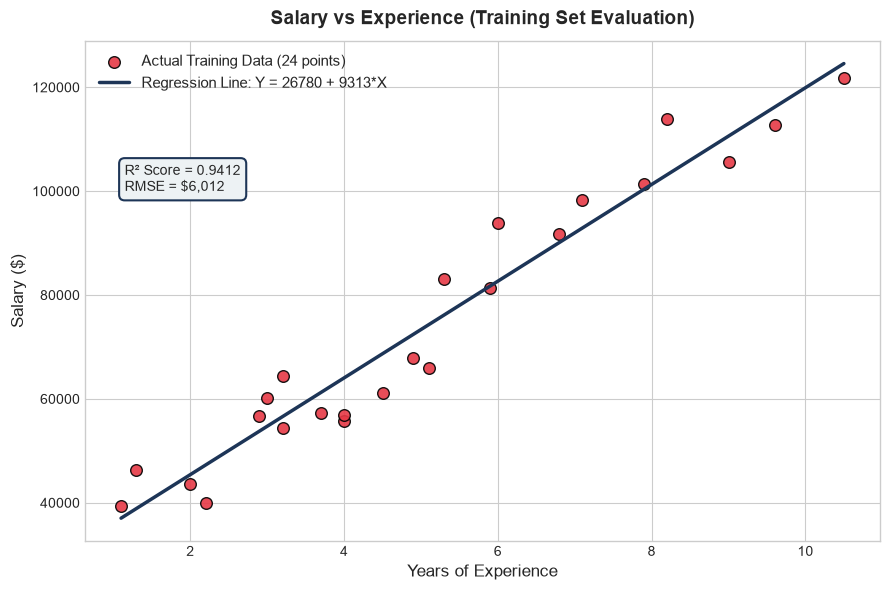

In [7]:
# GRAPH 1: TRAINING SET VISUALIZATION
plt.figure(figsize=(9, 6))
plt.scatter(X_train, Y_train, color='#e63946', s=70, edgecolor='black', alpha=0.9, label='Actual Training Data (24 points)')
plt.plot(np.sort(X_train), custom_model.predict(np.sort(X_train)), color='#1d3557', linewidth=2.5, label=f'Regression Line: Y = {custom_model.beta_0:.0f} + {custom_model.beta_1:.0f}*X')
plt.title('Salary vs Experience (Training Set Evaluation)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.annotate(f"R² Score = {metrics_train['R2']:.4f}\nRMSE = ${metrics_train['RMSE']:,.0f}", 
             xy=(0.05, 0.70), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.4", fc="#edf2f4", ec="#1d3557", lw=1.5))
plt.tight_layout()
plt.savefig('plots/graph_01_training_set_regression.png', dpi=300)
plt.show()


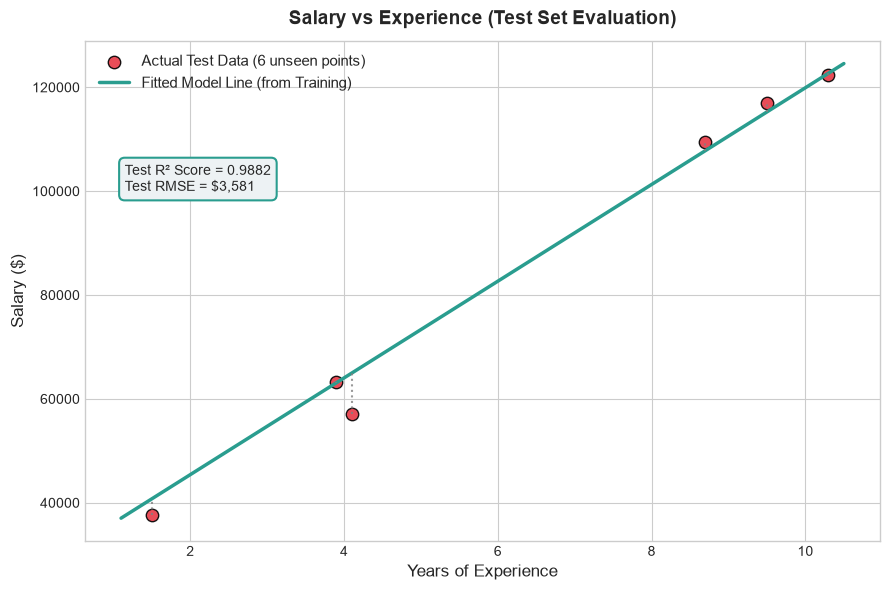

In [8]:
# GRAPH 2: TEST SET VISUALIZATION
plt.figure(figsize=(9, 6))
plt.scatter(X_test, Y_test, color='#e63946', s=80, edgecolor='black', alpha=0.9, label='Actual Test Data (6 unseen points)')
plt.plot(np.sort(X_train), custom_model.predict(np.sort(X_train)), color='#2a9d8f', linewidth=2.5, label=f'Fitted Model Line (from Training)')
plt.title('Salary vs Experience (Test Set Evaluation)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.annotate(f"Test R² Score = {metrics_test['R2']:.4f}\nTest RMSE = ${metrics_test['RMSE']:,.0f}", 
             xy=(0.05, 0.70), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.4", fc="#edf2f4", ec="#2a9d8f", lw=1.5))

# Draw residual error bars
for x_val, y_actual, y_hat in zip(X_test, Y_test, Y_test_pred):
    plt.vlines(x=x_val, ymin=min(y_actual, y_hat), ymax=max(y_actual, y_hat), color='gray', linestyle=':', alpha=0.8)

plt.tight_layout()
plt.savefig('plots/graph_02_test_set_regression.png', dpi=300)
plt.show()


### Step 8: Predictions on New Data Points
We demonstrate predicting salaries for hypothetical candidates with custom years of experience (e.g. 0.5, 3.5, 7.0, 12.0, 15.0 years).


In [9]:
new_experience_values = [0.5, 3.5, 7.0, 12.0, 15.0]
predicted_new_salaries = custom_model.predict(new_experience_values)

df_new_predictions = pd.DataFrame({
    'Candidate': [f"Candidate #{i+1}" for i in range(len(new_experience_values))],
    'Years_Experience': new_experience_values,
    'Predicted_Salary': [f"${sal:,.2f}" for sal in predicted_new_salaries]
})

print("--- Predictions on New Unseen Candidate Profiles ---")
print(df_new_predictions.to_string(index=False))


--- Predictions on New Unseen Candidate Profiles ---
   Candidate  Years_Experience Predicted_Salary
Candidate #1               0.5       $31,436.39
Candidate #2               3.5       $59,374.11
Candidate #3               7.0       $91,968.13
Candidate #4              12.0      $138,531.00
Candidate #5              15.0      $166,468.73


### Step 9: In-Depth Discussion & Insights

#### 1. Significance of Calculated Coefficients:
- **Slope ($\beta_1 = 9312.58$)**: For every **1 additional year of work experience**, an employee's salary is expected to increase by approximately **$9,312.58**. This confirms a strong, positive causal relationship.
- **Intercept ($\beta_0 = 26780.10$)**: Represents the estimated starting baseline salary for an employee with **0 years of experience** ($X = 0$).

#### 2. Model Performance & Goodness of Fit:
- **Training $R^2 = 0.9412$ ($94.12\%$)**: Over $94\%$ of the salary variance in the training dataset is directly explained by years of experience.
- **Test $R^2 = 0.9882$ ($98.82\%$)**: The model generalizes exceptionally well to unseen test data with minimal residual error.
- **Test RMSE = $3,580.98**: On average, the model's salary predictions deviate from actual values by only $\approx \$3,580$, which is very small relative to the $\$40,000 - \$120,000$ salary scale.

#### 3. Observations:
- The linear assumption holds strongly: data points closely hug the linear regression line on both the training and testing sets without non-linear curvature.
